In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    roc_auc_score, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:

# Define the Ulcer model architecture
class UlcerNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3)  # (3, 64, 64) -> (32, 62, 62)
        self.pool = nn.MaxPool2d(2, 2)     # (32, 62, 62) -> (32, 31, 31)
        self.conv2 = nn.Conv2d(32, 64, 3)  # (32, 31, 31) -> (64, 29, 29)
        # pooled: (64, 29, 29) -> (64, 14, 14)

        self.fc1 = nn.Linear(64 * 14 * 14, 32)
        self.fc2 = nn.Linear(32, 16)
        self.out = nn.Linear(16, 4)

    def forward(self, x):
        out = self.pool(F.relu(self.conv1(x)))
        out = self.pool(F.relu(self.conv2(out)))
        out = out.flatten(1)
        out = F.relu(self.fc1(out))
        out = F.relu(self.fc2(out))
        out = self.out(out)
        return out

# Load the trained model
model = UlcerNN()
model.load_state_dict(torch.load('ulcer_model_state.pth'))
model.eval()

print("Ulcer model loaded successfully!")

Ulcer model loaded successfully!


In [3]:
# Load and prepare the test data
# Define transforms
transforms = T.Compose([
    T.Resize((64, 64)),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Define custom dataset class
class UlcerDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Load dataset from ImageFolder
import torchvision
data = torchvision.datasets.ImageFolder(root='./archive/train', transform=transforms)

X = []
y = []

for images, labels in data:
    X.append(images)
    y.append(labels)

print(f"Loaded {len(X)} images")

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67, shuffle=True)

# Convert to tensors
X_train = torch.stack(X_train).float()
y_train = torch.tensor(y_train, dtype=torch.int64)

X_test = torch.stack(X_test).float()
y_test = torch.tensor(y_test, dtype=torch.int64)

# Create test dataset and loader
test_data = UlcerDataset(X_test, y_test, transform=None)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Test set size: {len(test_data)}")

Loaded 9639 images
Test set size: 1928


In [4]:

# Generate predictions on test set
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        output = model(images)
        probs = F.softmax(output, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        _, predictions = torch.max(output, 1)
        
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

print(f"Predictions shape: {all_preds.shape}")
print(f"Probabilities shape: {all_probs.shape}")
print(f"Labels shape: {all_labels.shape}")

Predictions shape: (1928,)
Probabilities shape: (1928, 4)
Labels shape: (1928,)


In [5]:
# Define class names for ulcer grades
class_names = ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']

# Calculate overall metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print("=" * 50)
print("OVERALL METRICS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("=" * 50)

OVERALL METRICS
Accuracy:  0.8766
Precision: 0.8785
Recall:    0.8766
F1-Score:  0.8766


In [6]:

# Detailed classification report
print("\nDETAILED CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0))



DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Grade 1     0.9310    0.8355    0.8806       468
     Grade 2     0.8584    0.9112    0.8840       439
     Grade 3     0.8462    0.8792    0.8624       538
     Grade 4     0.8820    0.8820    0.8820       483

    accuracy                         0.8766      1928
   macro avg     0.8794    0.8770    0.8772      1928
weighted avg     0.8785    0.8766    0.8766      1928



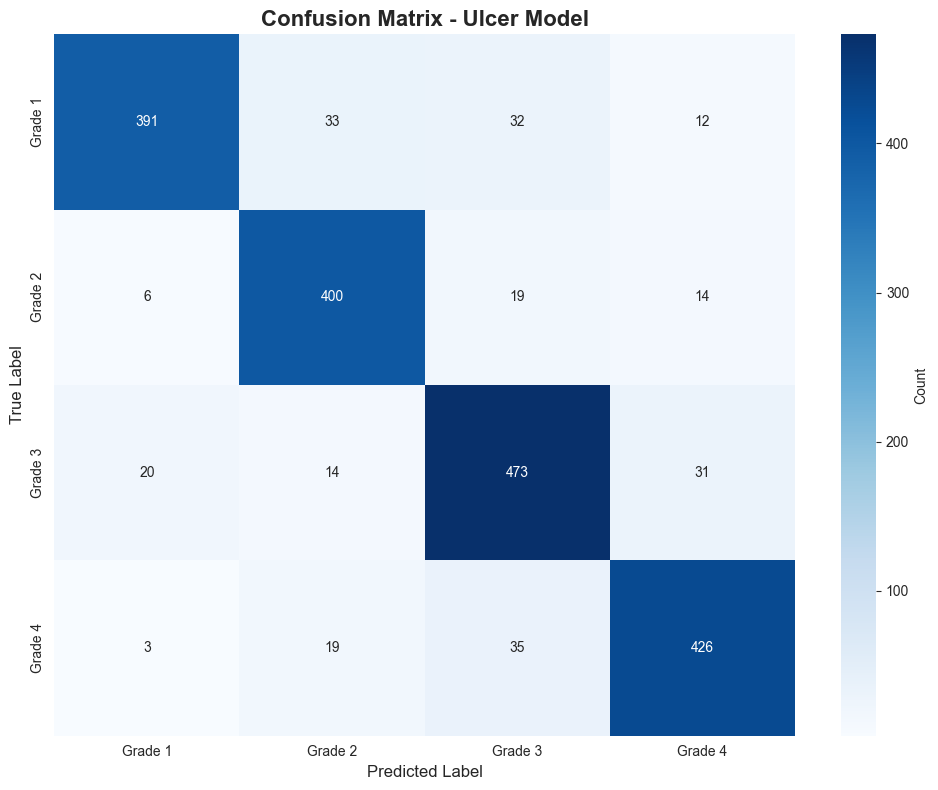

Confusion matrix saved as 'ulcer_confusion_matrix.png'


In [7]:

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Ulcer Model', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('ulcer_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as 'ulcer_confusion_matrix.png'")

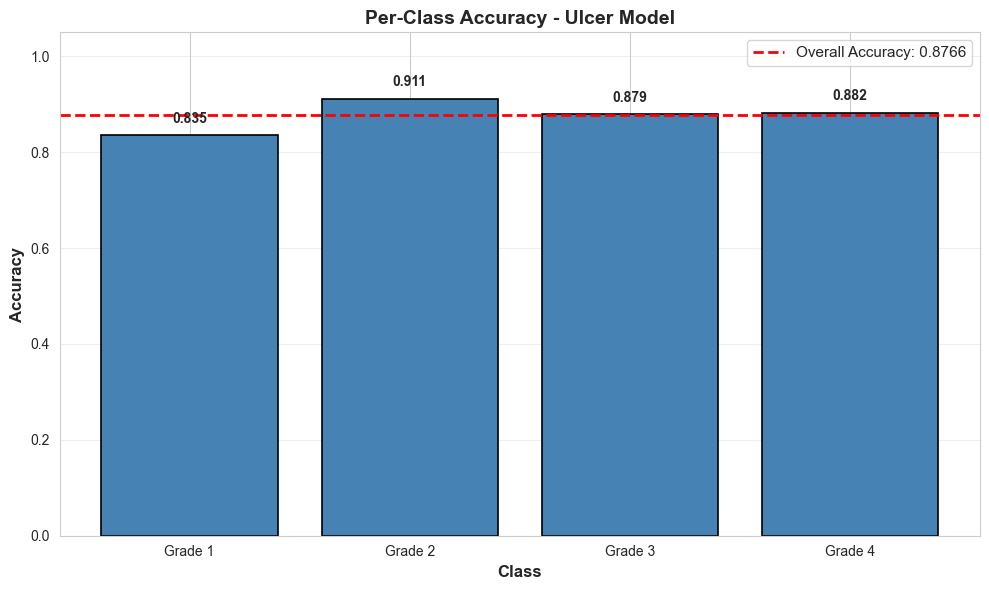

Per-class accuracy saved as 'ulcer_per_class_accuracy.png'


In [8]:


# Per-class accuracy metrics
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(class_names)), per_class_accuracy, color='steelblue', edgecolor='black', linewidth=1.2)
ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Accuracy - Ulcer Model', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=0)
ax.set_ylim([0, 1.05])
ax.axhline(y=accuracy, color='red', linestyle='--', linewidth=2, label=f'Overall Accuracy: {accuracy:.4f}')

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, per_class_accuracy)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ulcer_per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("Per-class accuracy saved as 'ulcer_per_class_accuracy.png'")

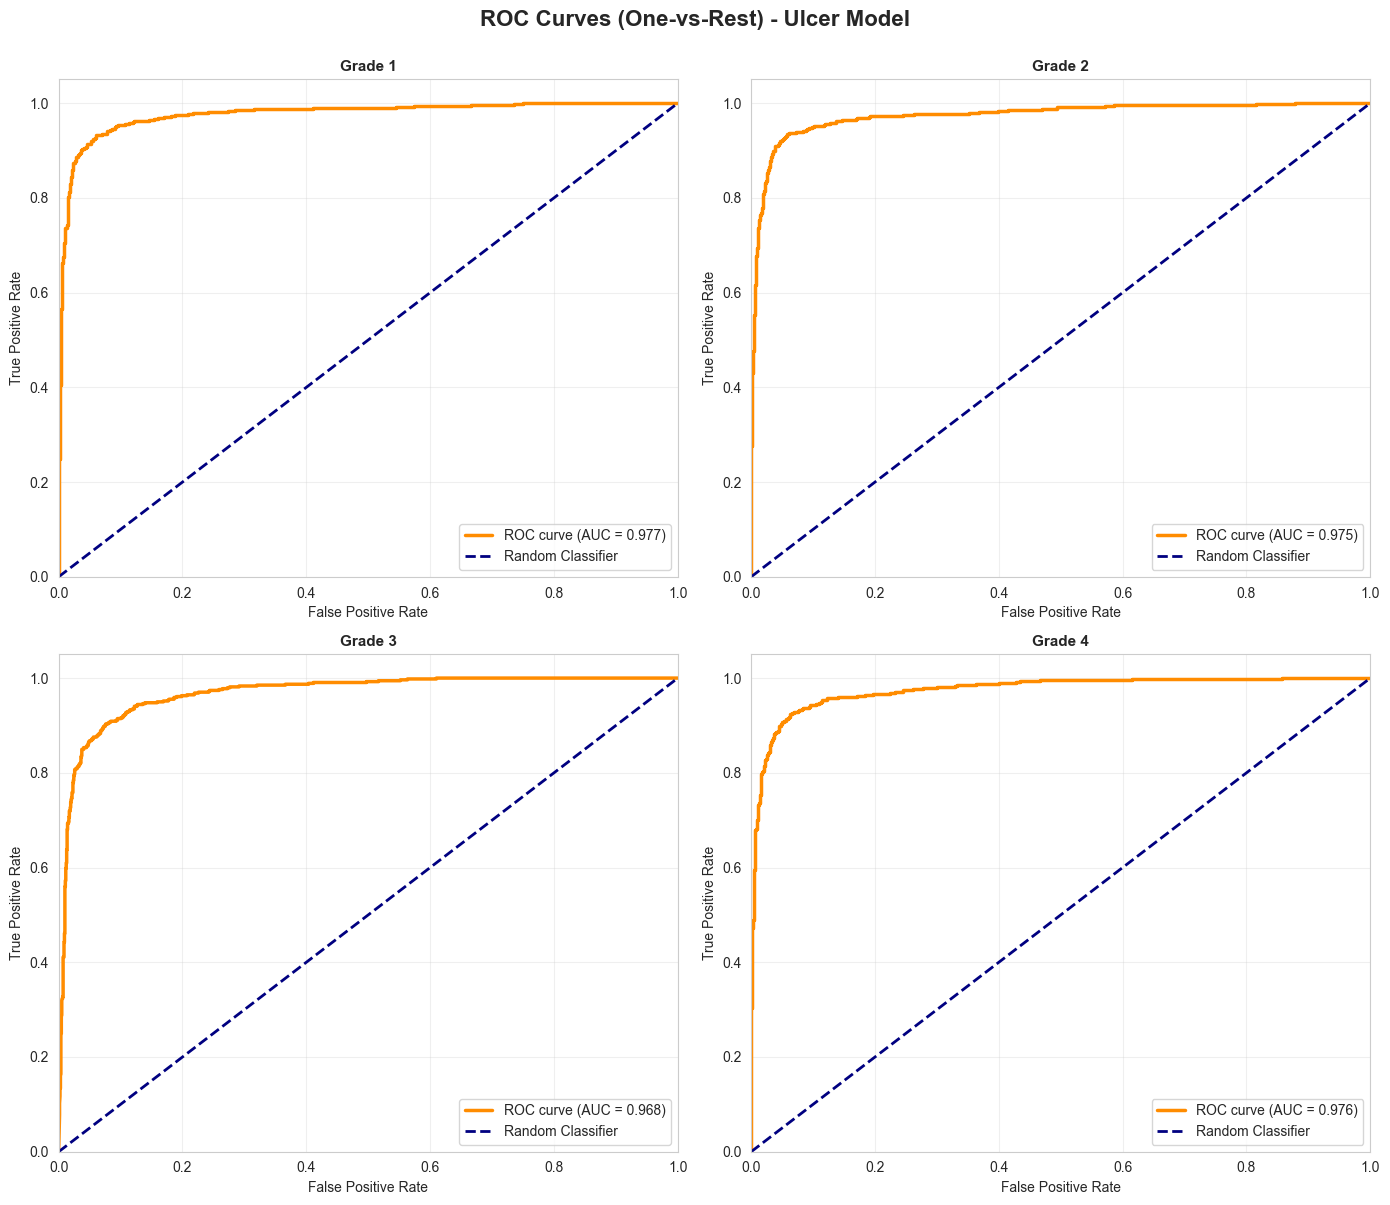

ROC curves saved as 'ulcer_roc_curves.png'


In [9]:

# ROC Curves (One-vs-Rest for each class)
n_classes = len(class_names)
y_bin = label_binarize(all_labels, classes=range(n_classes))

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    axes[i].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate', fontsize=10)
    axes[i].set_ylabel('True Positive Rate', fontsize=10)
    axes[i].set_title(f'{class_names[i]}', fontsize=11, fontweight='bold')
    axes[i].legend(loc="lower right", fontsize=10)
    axes[i].grid(alpha=0.3)

plt.suptitle('ROC Curves (One-vs-Rest) - Ulcer Model', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('ulcer_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("ROC curves saved as 'ulcer_roc_curves.png'")

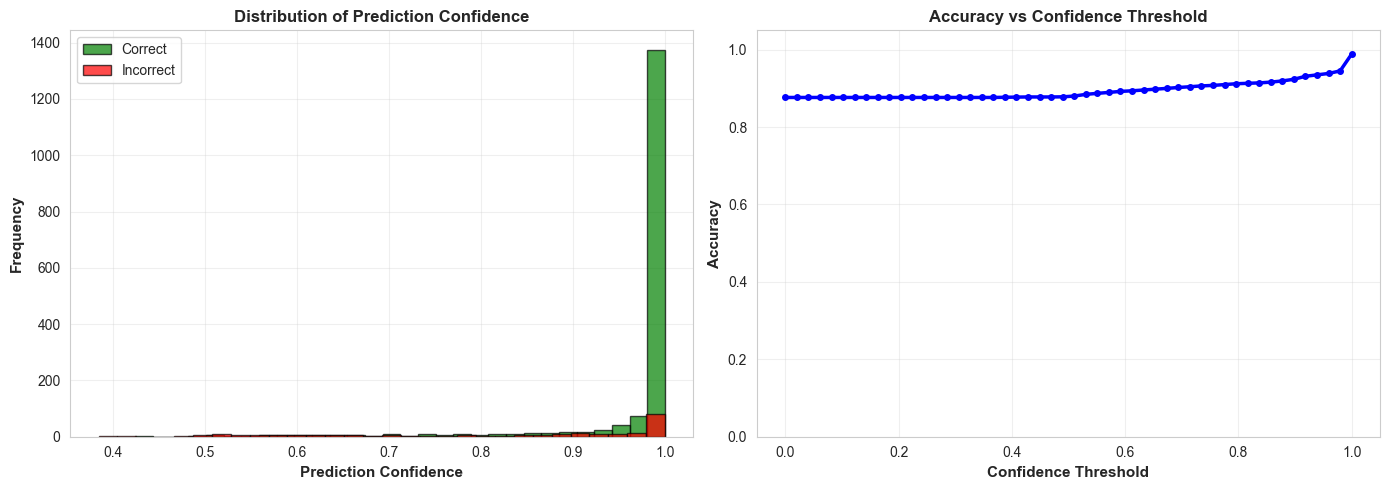

Confidence analysis saved as 'ulcer_confidence_analysis.png'


In [10]:

# Prediction confidence analysis
max_probs = np.max(all_probs, axis=1)
correct_mask = all_preds == all_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence distribution
axes[0].hist(max_probs[correct_mask], bins=30, alpha=0.7, label='Correct', color='green', edgecolor='black')
axes[0].hist(max_probs[~correct_mask], bins=30, alpha=0.7, label='Incorrect', color='red', edgecolor='black')
axes[0].set_xlabel('Prediction Confidence', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of Prediction Confidence', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy vs confidence threshold
thresholds = np.linspace(0, 1, 50)
accuracies = []
counts = []

for threshold in thresholds:
    mask = max_probs >= threshold
    if mask.sum() > 0:
        acc = (all_preds[mask] == all_labels[mask]).mean()
        accuracies.append(acc)
        counts.append(mask.sum())
    else:
        accuracies.append(0)
        counts.append(0)

axes[1].plot(thresholds, accuracies, 'b-', linewidth=2.5, marker='o', markersize=4)
axes[1].set_xlabel('Confidence Threshold', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
axes[1].set_title('Accuracy vs Confidence Threshold', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('ulcer_confidence_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confidence analysis saved as 'ulcer_confidence_analysis.png'")

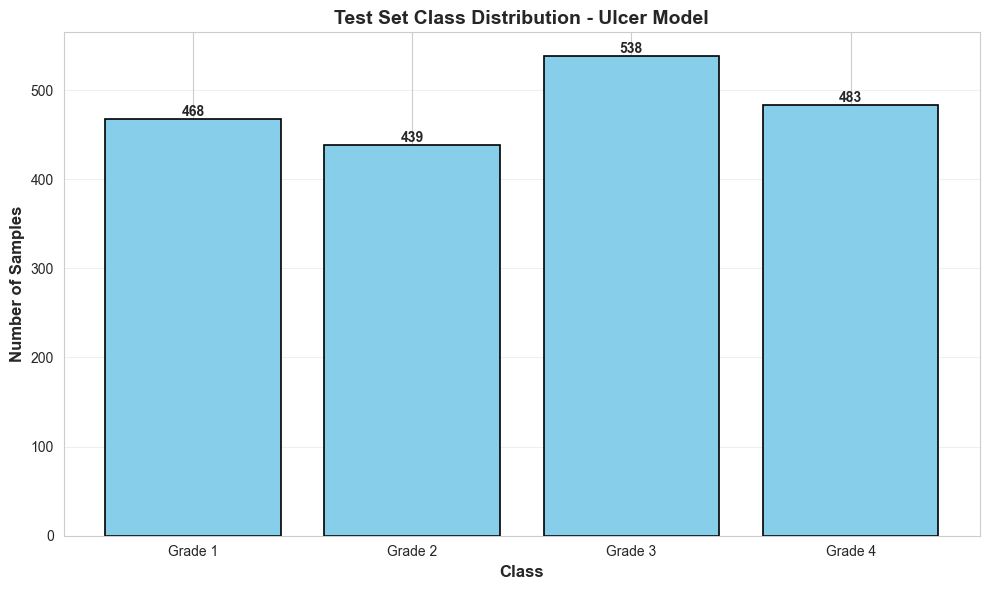

Class distribution saved as 'ulcer_class_distribution.png'


In [11]:

# Class distribution in test set
class_counts = np.bincount(all_labels, minlength=n_classes)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(n_classes), class_counts, color='skyblue', edgecolor='black', linewidth=1.2)
ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Test Set Class Distribution - Ulcer Model', fontsize=14, fontweight='bold')
ax.set_xticks(range(n_classes))
ax.set_xticklabels(class_names, rotation=0)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ulcer_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Class distribution saved as 'ulcer_class_distribution.png'")

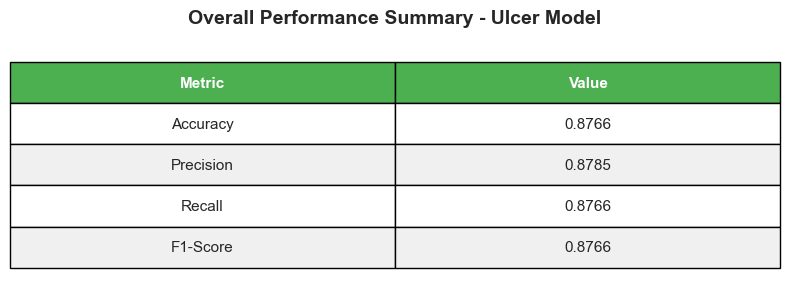

Summary metrics saved as 'ulcer_summary_metrics.png'


In [12]:

# Summary metrics table
summary_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [f'{accuracy:.4f}', f'{precision:.4f}', f'{recall:.4f}', f'{f1:.4f}']
}

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=[[m, v] for m, v in zip(summary_data['Metric'], summary_data['Value'])],
                colLabels=['Metric', 'Value'],
                cellLoc='center',
                loc='center',
                colWidths=[0.5, 0.5])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Color header
for i in range(2):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data['Metric']) + 1):
    for j in range(2):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')

plt.title('Overall Performance Summary - Ulcer Model', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('ulcer_summary_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Summary metrics saved as 'ulcer_summary_metrics.png'")